# ChurnGuard AI — Exploratory Data Analysis
Telco Customer Churn dataset (IBM)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# --- Load data ---
# NOTE: this notebook lives in notebooks/, so paths are relative to that folder
df = pd.read_csv("../data/raw/telco_churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# --- Basic structure ---
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Data cleaning

In [5]:
# --- Check for duplicate rows / duplicate IDs BEFORE dropping customerID ---
print("Lignes entièrement dupliquées:", df.duplicated().sum())
print("customerID dupliqués:", df["customerID"].duplicated().sum())

Lignes entièrement dupliquées: 0
customerID dupliqués: 0


`TotalCharges` is loaded as string and has 11 blank rows for customers
with tenure == 0 (brand new customers who haven't been billed yet).

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())
print("Tenure values for those rows:", df.loc[df["TotalCharges"].isna(), "tenure"].unique())

Missing TotalCharges: 11
Tenure values for those rows: [0]


In [7]:
# New customers -> TotalCharges should be 0, not missing
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [8]:
# Keep customerID aside (useful later for joining predictions back to source
# data / dashboards) but drop it from the modeling dataframe — it's a random
# unique identifier with zero predictive value and no generalization signal.
customer_ids = df["customerID"]
df = df.drop(columns=["customerID"])

## 2. Target distribution

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


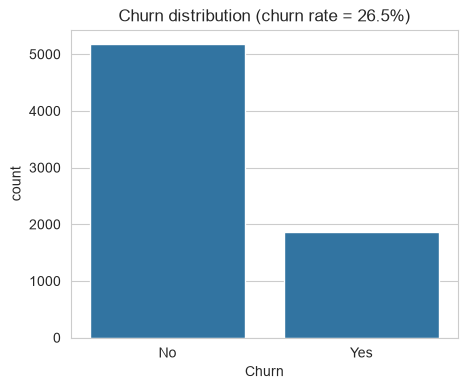

In [9]:
churn_rate = df["Churn"].value_counts(normalize=True)
print(churn_rate)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Churn", ax=ax)
ax.set_title(f"Churn distribution (churn rate = {churn_rate['Yes']:.1%})")
plt.show()

Class imbalance ~73/27. Not extreme, but accuracy alone will be
misleading later — we'll rely on ROC-AUC / PR-AUC / recall for the
churn class during modeling, and consider `class_weight="balanced"`
or SMOTE.

## 3. Numeric features

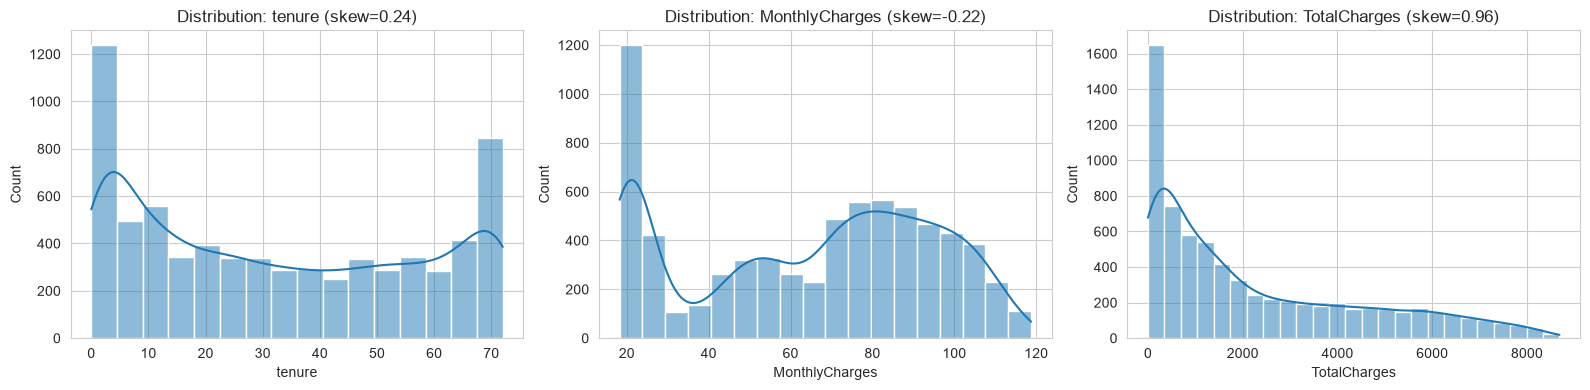

In [10]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# --- Univariate distributions (shape, skew) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution: {col} (skew={df[col].skew():.2f})")
plt.tight_layout()
plt.show()

In [11]:
# --- Outlier detection (IQR method) ---
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers ({n_outliers / len(df):.1%})")

tenure: 0 outliers (0.0%)
MonthlyCharges: 0 outliers (0.0%)
TotalCharges: 0 outliers (0.0%)


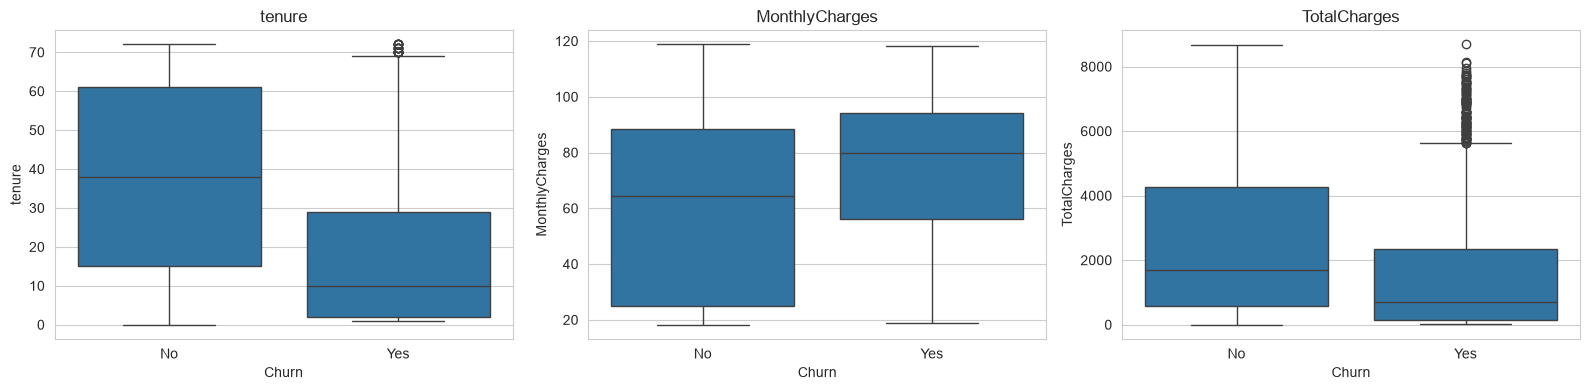

In [12]:
# --- Numeric features vs churn ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Expect: churners tend to have lower tenure and higher monthly charges —
classic "new customer, paying a lot, hasn't committed to a contract" profile.

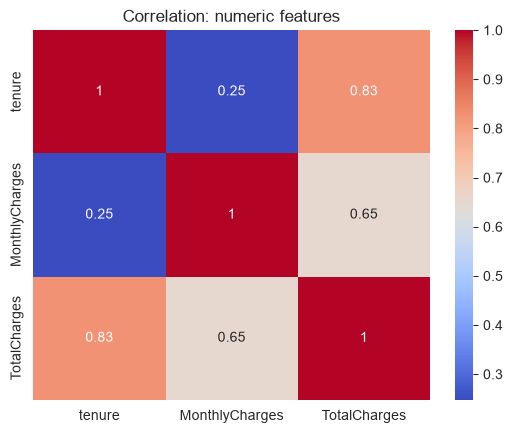

In [13]:
# --- Correlation among numeric features ---
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation: numeric features")
plt.show()

In [14]:
# --- Multicollinearity / leakage check ---
# TotalCharges is mathematically close to tenure * MonthlyCharges.
# Worth knowing before modeling: near-perfect correlation here means
# TotalCharges carries mostly redundant information.
_check = df["tenure"] * df["MonthlyCharges"]
correlation = _check.corr(df["TotalCharges"])
print(f"Corrélation TotalCharges vs (tenure × MonthlyCharges): {correlation:.4f}")

Corrélation TotalCharges vs (tenure × MonthlyCharges): 0.9996


In [15]:
# --- Statistical significance: numeric features vs churn (t-test) ---
print("T-test — significativité de chaque variable numérique vs Churn\n")
for col in numeric_cols:
    yes = df.loc[df["Churn"] == "Yes", col]
    no = df.loc[df["Churn"] == "No", col]
    t_stat, p = ttest_ind(yes, no, equal_var=False)
    signif = "significatif" if p < 0.05 else "pas significatif"
    print(f"{col:20s} p-value={p:.6f}  -> {signif}")

T-test — significativité de chaque variable numérique vs Churn

tenure               p-value=0.000000  -> significatif
MonthlyCharges       p-value=0.000000  -> significatif
TotalCharges         p-value=0.000000  -> significatif


## 4. Categorical features vs churn

In [16]:
categorical_cols = [c for c in df.columns if df[c].dtype == "object" and c != "Churn"]
print(categorical_cols)

[]


In [17]:
def churn_rate_by_category(df, col):
    return (
        df.groupby(col)["Churn"]
        .apply(lambda s: (s == "Yes").mean())
        .sort_values(ascending=False)
    )

for col in ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity"]:
    print(f"\n--- {col} ---")
    print(churn_rate_by_category(df, col))


--- Contract ---
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64

--- PaymentMethod ---
PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64

--- TechSupport ---
TechSupport
No                     0.416355
Yes                    0.151663
No internet service    0.074050
Name: Churn, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn, dtype: float64


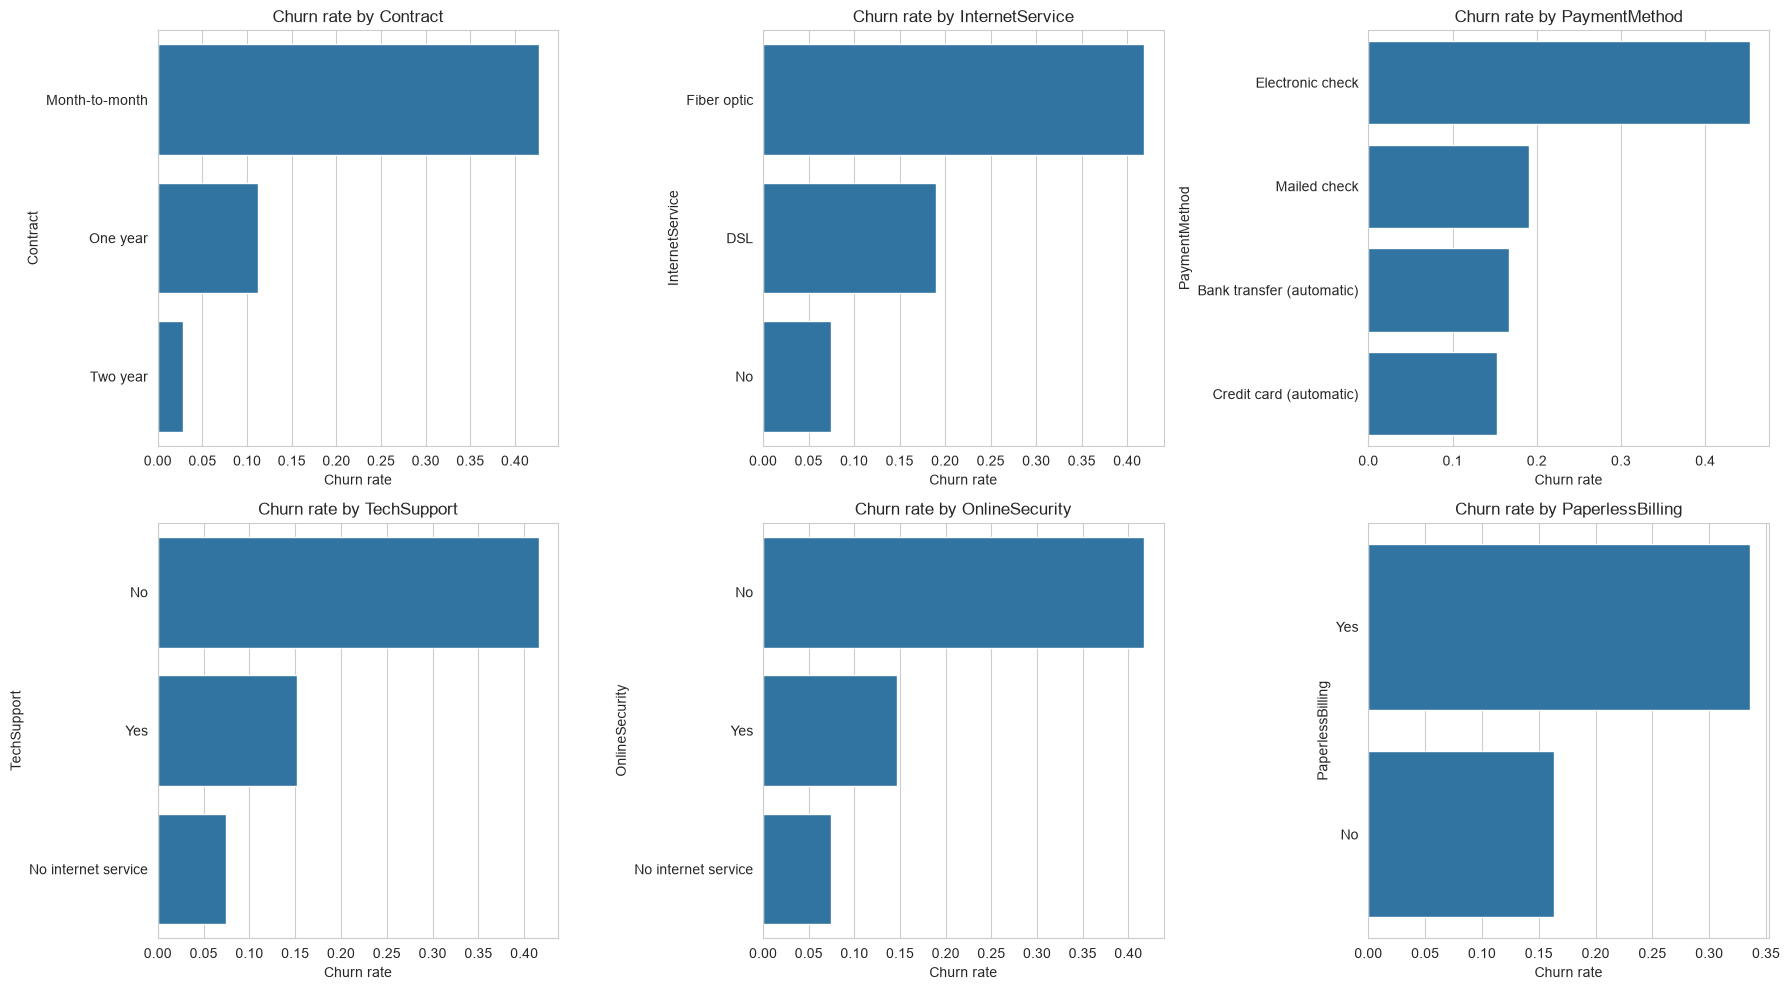

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cols_to_plot = ["Contract", "InternetService", "PaymentMethod",
                 "TechSupport", "OnlineSecurity", "PaperlessBilling"]
for ax, col in zip(axes.flat, cols_to_plot):
    rates = churn_rate_by_category(df, col)
    sns.barplot(x=rates.values, y=rates.index, ax=ax)
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("Churn rate")
plt.tight_layout()
plt.show()

In [19]:
# --- Statistical significance: categorical features vs churn (Chi²) ---
print("Chi² test — significativité de chaque variable catégorielle vs Churn\n")
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    signif = "significatif" if p < 0.05 else "pas significatif"
    print(f"{col:20s} p-value={p:.4f}  -> {signif}")

Chi² test — significativité de chaque variable catégorielle vs Churn



## 5. Feature engineering ideas to carry into modeling
- `tenure_bucket`: bin tenure into 0-12 / 12-24 / 24-48 / 48+ months
- `num_services`: count of add-on services subscribed (OnlineSecurity,
  OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies)
- `avg_charge_per_service`: TotalCharges / max(num_services, 1)
- Month-to-month contract flag (strongest churn signal expected)
- No-internet-service customers as a distinct segment
- Given TotalCharges ≈ tenure × MonthlyCharges, consider dropping one of
  the three or combining them to reduce multicollinearity for linear models
  (not an issue for tree-based models like XGBoost)

## 6. Key takeaways
- Overall churn rate: ~26.5%, moderate class imbalance
- No duplicate rows or IDs found
- Strongest apparent drivers (confirmed by Chi²/t-test): contract type,
  tenure, internet service type, presence of tech support / online security
- Numeric features are right-skewed; consider scaling for linear models,
  not needed for tree-based models (XGBoost)
- TotalCharges is highly correlated with tenure × MonthlyCharges — a
  multicollinearity point to keep in mind during modeling
- Evaluate with ROC-AUC and PR-AUC rather than accuracy given the imbalance

In [20]:
# --- Save cleaned dataset for the next stage (src/data_prep.py) ---
os.makedirs("../data/processed", exist_ok=True)
df_to_save = df.copy()
df_to_save.insert(0, "customerID", customer_ids)
df_to_save.to_csv("../data/processed/telco_churn_cleaned.csv", index=False)
print("Sauvegardé:", os.path.abspath("../data/processed/telco_churn_cleaned.csv"))

Sauvegardé: c:\Users\Miraa\Desktop\summer pro\Churn-Prediction-MLops\data\processed\telco_churn_cleaned.csv
